In [7]:
install.packages("MASS")
library(MASS)

package 'MASS' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\jet_v\AppData\Local\Temp\RtmpYX4c5W\downloaded_packages


Warning message:
"package 'MASS' was built under R version 4.5.3"


In [13]:
d <- read.csv("Forum_Posts.csv", header = TRUE)
#summary(d)
model1 <- glm(posts ~ ., data = d, family = poisson)
summary(model1)


Call:
glm(formula = posts ~ ., family = poisson, data = d)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -4.744e+00  5.193e-01  -9.135  < 2e-16 ***
totalPosts   7.963e-06  1.238e-06   6.433 1.25e-10 ***
readingRate  1.125e-01  4.963e-02   2.266   0.0235 *  
postStock    6.735e-03  4.733e-03   1.423   0.1548    
wknd        -8.691e-02  4.127e-02  -2.106   0.0352 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 20863  on 11999  degrees of freedom
Residual deviance: 20762  on 11995  degrees of freedom
AIC: 25459

Number of Fisher Scoring iterations: 6


In [6]:
pearson_chi2 <- sum(residuals(model1, type = "pearson")^2)
df_residual <- df.residual(model1)

sig2_hat <- pearson_chi2 / df_residual
print(sig2_hat)

[1] 5.168645


In [8]:
model2 <- glm.nb(posts ~ ., data = d)
summary(model2)


Call:
glm.nb(formula = posts ~ ., data = d, init.theta = 0.1154693143, 
    link = log)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -4.608e+00  1.103e+00  -4.178 2.94e-05 ***
totalPosts   7.539e-06  2.560e-06   2.945  0.00323 ** 
readingRate  1.150e-01  1.044e-01   1.101  0.27075    
postStock    6.864e-03  1.013e-02   0.678  0.49803    
wknd        -8.655e-02  8.568e-02  -1.010  0.31243    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(0.1155) family taken to be 1)

    Null deviance: 4854.1  on 11999  degrees of freedom
Residual deviance: 4831.3  on 11995  degrees of freedom
AIC: 16309

Number of Fisher Scoring iterations: 1


              Theta:  0.11547 
          Std. Err.:  0.00402 

 2 x log-likelihood:  -16297.14900 

In [9]:
AIC(model1)
BIC(model1)

[1] 25458.83

[1] 25495.8

In [10]:
AIC(model2)
BIC(model2)

[1] 16309.15

[1] 16353.51

In [11]:
k <- 0:20

mean_d <- as.data.frame(lapply(d[, -1], mean))
lambda <- predict(model1, newdata = mean_d, type = "response")
mu_nb <- predict(model2, newdata = mean_d, type = "response")

theta = model2$theta

p1 <- dpois(k, lambda = lambda)
p2 <- dnbinom(k, size = theta, mu = mu_nb)

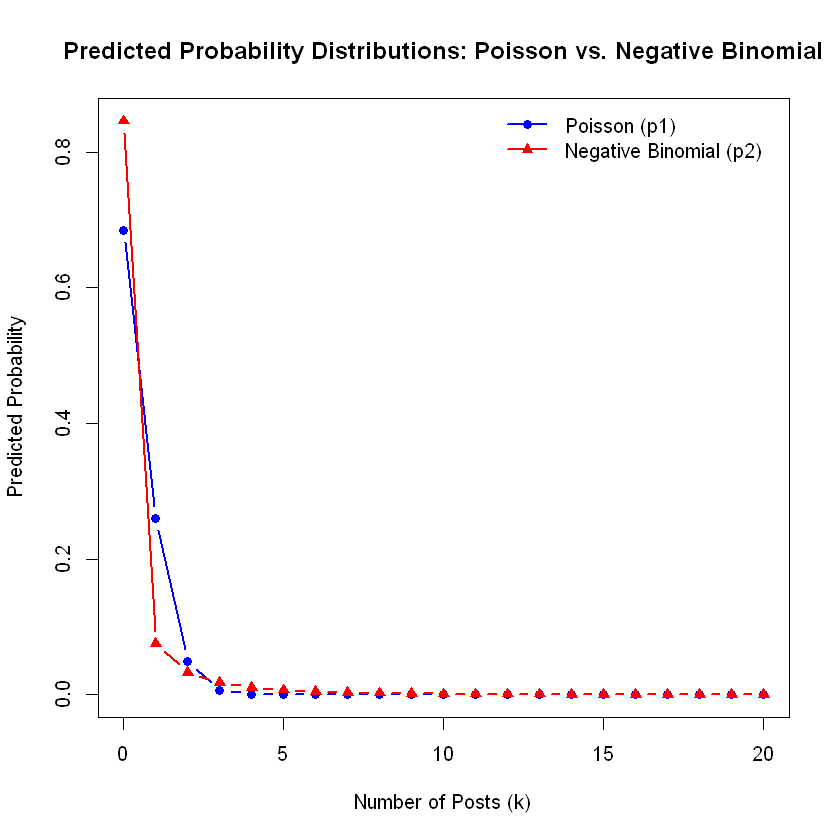

In [12]:
# 5. Plot p1 and p2 against k on the same plot
plot(k, p1, type = "b", col = "blue", pch = 16, lwd = 2,
     ylim = c(0, max(c(p1, p2))),
     xlab = "Number of Posts (k)", ylab = "Predicted Probability",
     main = "Predicted Probability Distributions: Poisson vs. Negative Binomial")

# Add the Negative Binomial lines/points
lines(k, p2, type = "b", col = "red", pch = 17, lwd = 2)

# Add a helpful legend
legend("topright", legend = c("Poisson (p1)", "Negative Binomial (p2)"),
       col = c("blue", "red"), pch = c(16, 17), lwd = 2, bty = "n")